# Modelos de Clasificación — Rezago Académico por Área en Saber 11 (Bolívar)
**Proyecto 2 — Analítica Computacional para la Toma de Decisiones**  
**Universidad de los Andes**  
**Autor:** Daniel David Burgos Lafont  

## Contexto

Familia de cinco modelos de clasificación binaria que estiman la probabilidad de **rezago académico** en cada área del Saber 11 para estudiantes del departamento de Bolívar. El **modelo oficial del proyecto y del futuro dashboard es una red neuronal en TensorFlow/Keras**. Se mantienen como modelos comparativos `LogisticRegression` (baseline) y `HistGradientBoostingClassifier` (benchmark).

## Pregunta de negocio

> ¿En qué áreas del Saber 11 presentan los estudiantes mayor probabilidad de rezago académico, y cómo puede la Secretaría de Educación de Bolívar priorizar intervenciones diferenciadas por competencia según el perfil socioeconómico, familiar y escolar del estudiante?

## Definición operativa de rezago

$$\text{rezago\_area}_i = 1 \quad \text{si} \quad \text{punt\_area}_i \le P_{25}^{\text{train}}(\text{punt\_area})$$

$P_{25}$ se calcula **solo sobre el conjunto de entrenamiento** para evitar fuga del test al definir el umbral.

## 1. Imports y configuración

In [1]:
import sys
!{sys.executable} -m pip install tensorflow pandas numpy scikit-learn matplotlib mlflow joblib
import os
import json
import random
import warnings
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

import joblib
import mlflow

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# No silenciamos warnings globalmente. Solo eliminamos FutureWarning (ruido).
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
# Reducir verbosidad de TF en consola
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Semilla
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

print(f"Python      : {platform.python_version()}")
print(f"pandas      : {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"tensorflow  : {tf.__version__}")
print(f"mlflow      : {mlflow.__version__}")



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Python      : 3.12.0
pandas      : 2.3.3
scikit-learn: 1.8.0
tensorflow  : 2.21.0
mlflow      : 3.12.0


## 2. Carga del CSV limpio

In [2]:
df = pd.read_csv("DatosSaber11_Bolivar_limpio_todas_columnas.csv")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()


Filas: 122,866
Columnas: 52


,estu_consecutivo,periodo,estu_fechanacimiento,edad,estu_genero,cole_area_ubicacion,cole_mcpio_ubicacion,cole_calendario,cole_bilingue,cole_naturaleza,cole_genero,cole_caracter,fami_estratovivienda,fami_tienecomputador,fami_tieneinternet,fami_educacionmadre,fami_educacionpadre,punt_ingles,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_global,estu_tipodocumento,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_depto_ubicacion,cole_jornada,cole_nombre_establecimiento,cole_nombre_sede,cole_sede_principal,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,estu_depto_presentacion,estu_depto_reside,estu_estadoinvestigacion,estu_estudiante,estu_mcpio_presentacion,estu_mcpio_reside,estu_nacionalidad,estu_pais_reside,estu_privado_libertad,fami_cuartoshogar,fami_personashogar,fami_tieneautomovil,fami_tienelavadora,desemp_ingles
0,SB11202240343561,20224,20/05/2005,17,M,URBANO,ARJONA,A,N,OFICIAL,MIXTO,ACADEMICO,ESTRATO 1,NO,NO,SECUNDARIA (BACHILLERATO) COMPLETA,PRIMARIA COMPLETA,51.0,47.0,49,51,32,226.0,TI,113052000172,113052000172,13,13052,4499,BOLIVAR,MAÑANA,INSTITUCIÓN EDUCATIVA BENJAMIN HERRERA,I.E. BENJAMIN HERRERA - SEDE PRINCIPAL,S,13,13052,13,13052,BOLIVAR,BOLIVAR,PUBLICAR,ESTUDIANTE,ARJONA,ARJONA,COLOMBIA,COLOMBIA,N,Uno,3 a 4,No,Si,A1
1,SB11202240223211,20224,07/07/2005,17,M,URBANO,CARTAGENA DE INDIAS,A,N,OFICIAL,MIXTO,TECNICO/ACADEMICO,ESTRATO 3,SI,SI,EDUCACION PROFESIONAL COMPLETA,EDUCACION PROFESIONAL COMPLETA,100.0,62.0,68,67,71,348.0,TI,113001003053,113001003053,13,13001,4481,BOLIVAR,TARDE,INSTITUCION EDUCATIVA SOLEDAD ACOSTA DE SAMPER,INSTITUCION EDUCATIVA SOLEDAD ACOSTA DE SAMPER,S,13,13001,13,13001,BOLIVAR,BOLIVAR,PUBLICAR,ESTUDIANTE,CARTAGENA DE INDIAS,CARTAGENA DE INDIAS,COLOMBIA,COLOMBIA,N,Tres,5 a 6,No,Si,B+
2,SB11202240503276,20224,27/05/2006,16,F,URBANO,SAN JACINTO DEL CAUCA,A,N,OFICIAL,MIXTO,ACADEMICO,ESTRATO 3,NO,NO,SECUNDARIA (BACHILLERATO) COMPLETA,NINGUNO,39.0,26.0,36,39,25,160.0,TI,213006001649,213006001649,13,13655,86751,BOLIVAR,MAÑANA,INSTITUCION EDUCATIVA PLACIDO RETAMOZA,INSTITUCION EDUCATIVA PLACIDO RETAMOZA,S,5,5495,13,13655,ANTIOQUIA,BOLIVAR,PUBLICAR,ESTUDIANTE,NECHÍ,SAN JACINTO DEL CAUCA,COLOMBIA,COLOMBIA,N,Tres,3 a 4,No,Si,A-
3,SB11202240231496,20224,05/05/2005,17,M,RURAL,CARTAGENA DE INDIAS,A,N,OFICIAL,MIXTO,ACADEMICO,SIN ESTRATO,NO,SI,SECUNDARIA (BACHILLERATO) COMPLETA,SECUNDARIA (BACHILLERATO) COMPLETA,42.0,25.0,35,36,32,164.0,TI,213001027020,213001027020,13,13001,314641,BOLIVAR,MAÑANA,INSTITUCION EDUCATIVA DOMINGO BENKOS BIOHO,INSTITUCION EDUCATIVA DOMINGO BENKOS BIOHO,S,13,13001,13,13001,BOLIVAR,BOLIVAR,PUBLICAR,ESTUDIANTE,CARTAGENA DE INDIAS,CARTAGENA DE INDIAS,COLOMBIA,COLOMBIA,N,Dos,3 a 4,No,Si,A-
4,SB11202240177303,20224,24/09/2004,18,F,URBANO,CARTAGENA DE INDIAS,A,N,OFICIAL,MIXTO,ACADEMICO,ESTRATO 1,SI,SI,TECNICA O TECNOLOGICA INCOMPLETA,TECNICA O TECNOLOGICA INCOMPLETA,45.0,52.0,52,51,48,252.0,TI,113001000348,113001000348,13,13001,142539,BOLIVAR,NOCHE,INSTITUCION EDUCATIVA AMBIENTALISTA DE CARTAGENA,INSTITUCION EDUCATIVA AMBIENTALISTA DE CARTAGENA,S,13,13001,13,13001,BOLIVAR,BOLIVAR,PUBLICAR,ESTUDIANTE,CARTAGENA DE INDIAS,CARTAGENA DE INDIAS,COLOMBIA,COLOMBIA,N,Tres,3 a 4,No,Si,A-


## 3. Revisión de tipos y columnas

In [3]:
print("Tipos de datos:")
print(df.dtypes)
print(f"\nNulos totales: {int(df.isna().sum().sum())}")
print(f"Filas duplicadas: {int(df.duplicated().sum())}")


Tipos de datos:
estu_consecutivo                  object
periodo                            int64
estu_fechanacimiento              object
edad                               int64
estu_genero                       object
cole_area_ubicacion               object
cole_mcpio_ubicacion              object
cole_calendario                   object
cole_bilingue                     object
cole_naturaleza                   object
cole_genero                       object
cole_caracter                     object
fami_estratovivienda              object
fami_tienecomputador              object
fami_tieneinternet                object
fami_educacionmadre               object
fami_educacionpadre               object
punt_ingles                      float64
punt_matematicas                 float64
punt_lectura_critica               int64
punt_c_naturales                   int64
punt_sociales_ciudadanas           int64
punt_global                      float64
estu_tipodocumento                object


## 4. Exploración inicial de los puntajes por área

In [4]:
areas_puntaje = {
    "Matemáticas":           "punt_matematicas",
    "Lectura Crítica":       "punt_lectura_critica",
    "Ciencias Naturales":    "punt_c_naturales",
    "Sociales y Ciudadanas": "punt_sociales_ciudadanas",
    "Inglés":                "punt_ingles",
}
df[list(areas_puntaje.values())].describe().round(2)


,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles
count,122866.00,122866.00,122866.00,122866.00,122866.00
mean,47.07,48.85,47.19,45.77,47.34
std,11.58,10.38,10.30,11.48,11.40
min,0.00,0.00,0.00,0.00,0.00
25%,39.00,41.00,40.00,37.00,40.00
50%,46.00,48.00,46.00,45.00,45.00
75%,54.00,56.00,54.00,53.00,52.00
max,100.00,100.00,100.00,100.00,100.00


## 5. Selección de predictores

Excluimos cualquier columna cuyo nombre empiece por `punt_`, `desemp_`, `percentil_`, `decil_`, `cuartil_` o `rezago_`, más identificadores y fechas crudas.


In [5]:
PREDICTORES_SUGERIDOS = [
    "edad", "periodo",
    "estu_genero",
    "cole_area_ubicacion", "cole_mcpio_ubicacion", "cole_calendario", "cole_bilingue",
    "cole_naturaleza", "cole_genero", "cole_caracter", "cole_jornada",
    "fami_estratovivienda", "fami_tienecomputador", "fami_tieneinternet",
    "fami_tieneautomovil", "fami_tienelavadora",
    "fami_educacionmadre", "fami_educacionpadre",
    "fami_cuartoshogar", "fami_personashogar",
]

EXCLUSIONES_EXPLICITAS = {
    "punt_global", "punt_matematicas", "punt_lectura_critica",
    "punt_c_naturales", "punt_sociales_ciudadanas", "punt_ingles",
    "desemp_ingles",
    "estu_consecutivo", "estu_fechanacimiento",
}

PREFIJOS_PROHIBIDOS = ("punt_", "desemp_", "percentil_", "decil_", "cuartil_", "rezago_")


def es_predictor_valido(col, exclusiones_extra=None):
    exclusiones_extra = exclusiones_extra or set()
    if col in EXCLUSIONES_EXPLICITAS or col in exclusiones_extra:
        return False
    for pref in PREFIJOS_PROHIBIDOS:
        if col.startswith(pref):
            return False
    return True


disponibles = [c for c in PREDICTORES_SUGERIDOS if c in df.columns]
predictores = [c for c in disponibles if es_predictor_valido(c)]
descartados = [c for c in PREDICTORES_SUGERIDOS if c not in df.columns]

print(f"Predictores finales ({len(predictores)}):")
for p in predictores:
    print(f"  - {p}")
if descartados:
    print(f"\nSugeridos NO encontrados en CSV: {descartados}")

# Anti-fuga assert
malos = [c for c in predictores if any(c.startswith(p) for p in PREFIJOS_PROHIBIDOS)
         or c in EXCLUSIONES_EXPLICITAS]
assert len(malos) == 0, f"FUGA DETECTADA en predictores: {malos}"
print("\n[OK] Verificación anti-fuga.")


Predictores finales (20):
  - edad
  - periodo
  - estu_genero
  - cole_area_ubicacion
  - cole_mcpio_ubicacion
  - cole_calendario
  - cole_bilingue
  - cole_naturaleza
  - cole_genero
  - cole_caracter
  - cole_jornada
  - fami_estratovivienda
  - fami_tienecomputador
  - fami_tieneinternet
  - fami_tieneautomovil
  - fami_tienelavadora
  - fami_educacionmadre
  - fami_educacionpadre
  - fami_cuartoshogar
  - fami_personashogar

[OK] Verificación anti-fuga.


In [ ]:
PREDICTORES_SUGERIDOS = [
    "edad", "periodo",
    "estu_genero",
    "cole_area_ubicacion", "cole_mcpio_ubicacion", "cole_calendario", "cole_bilingue",
    "cole_naturaleza", "cole_genero", "cole_caracter", "cole_jornada",
    "fami_estratovivienda", "fami_tienecomputador", "fami_tieneinternet",
    "fami_tieneautomovil", "fami_tienelavadora",
    "fami_educacionmadre", "fami_educacionpadre",
    "fami_cuartoshogar", "fami_personashogar",
]

EXCLUSIONES_EXPLICITAS = {
    "punt_global", "punt_matematicas", "punt_lectura_critica",
    "punt_c_naturales", "punt_sociales_ciudadanas", "punt_ingles",
    "desemp_ingles",
    "estu_consecutivo", "estu_fechanacimiento",
}

PREFIJOS_PROHIBIDOS = ("punt_", "desemp_", "percentil_", "decil_", "cuartil_", "rezago_")


def es_predictor_valido(col, exclusiones_extra=None):
    exclusiones_extra = exclusiones_extra or set()
    if col in EXCLUSIONES_EXPLICITAS or col in exclusiones_extra:
        return False
    for pref in PREFIJOS_PROHIBIDOS:
        if col.startswith(pref):
            return False
    return True


disponibles = [c for c in PREDICTORES_SUGERIDOS if c in df.columns]
predictores = [c for c in disponibles if es_predictor_valido(c)]
descartados = [c for c in PREDICTORES_SUGERIDOS if c not in df.columns]

print(f"Predictores finales ({len(predictores)}):")
for p in predictores:
    print(f"  - {p}")
if descartados:
    print(f"\nSugeridos NO encontrados en CSV: {descartados}")

# Anti-fuga assert
malos = [c for c in predictores if any(c.startswith(p) for p in PREFIJOS_PROHIBIDOS)
         or c in EXCLUSIONES_EXPLICITAS]
assert len(malos) == 0, f"FUGA DETECTADA en predictores: {malos}"
print("\n[OK] Verificación anti-fuga.")


Predictores finales (20):
  - edad
  - periodo
  - estu_genero
  - cole_area_ubicacion
  - cole_mcpio_ubicacion
  - cole_calendario
  - cole_bilingue
  - cole_naturaleza
  - cole_genero
  - cole_caracter
  - cole_jornada
  - fami_estratovivienda
  - fami_tienecomputador
  - fami_tieneinternet
  - fami_tieneautomovil
  - fami_tienelavadora
  - fami_educacionmadre
  - fami_educacionpadre
  - fami_cuartoshogar
  - fami_personashogar

[OK] Verificación anti-fuga.


## 6. Tipos numéricos vs categóricos y cardinalidad

In [6]:
cols_numericas = [c for c in ["edad", "periodo"] if c in predictores]
cols_categoricas = [c for c in predictores if c not in cols_numericas]

df_modelo = df[predictores + list(areas_puntaje.values())].copy()
for c in cols_numericas:
    df_modelo[c] = pd.to_numeric(df_modelo[c], errors="coerce")
for c in cols_categoricas:
    df_modelo[c] = df_modelo[c].astype(str)

print(f"Numéricas   ({len(cols_numericas)}): {cols_numericas}")
print(f"Categóricas ({len(cols_categoricas)}): {cols_categoricas}")
print("\nCardinalidad de categóricas:")
for c in sorted(cols_categoricas, key=lambda x: -df_modelo[x].nunique()):
    n = df_modelo[c].nunique()
    flag = "  [alta]" if n > 50 else ""
    print(f"  {c:30s}: {n:4d} categorías{flag}")


Numéricas   (2): ['edad', 'periodo']
Categóricas (18): ['estu_genero', 'cole_area_ubicacion', 'cole_mcpio_ubicacion', 'cole_calendario', 'cole_bilingue', 'cole_naturaleza', 'cole_genero', 'cole_caracter', 'cole_jornada', 'fami_estratovivienda', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tieneautomovil', 'fami_tienelavadora', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_cuartoshogar', 'fami_personashogar']

Cardinalidad de categóricas:
  cole_mcpio_ubicacion          :   47 categorías
  fami_personashogar            :   17 categorías
  fami_educacionmadre           :   12 categorías
  fami_educacionpadre           :   12 categorías
  fami_cuartoshogar             :   11 categorías
  fami_estratovivienda          :    7 categorías
  cole_jornada                  :    6 categorías
  cole_caracter                 :    4 categorías
  cole_genero                   :    3 categorías
  estu_genero                   :    2 categorías
  cole_area_ubicacion           :    2 catego

## 7. Partición train/test única y cálculo de $P_{25}$ solo sobre train

In [7]:
X_full = df_modelo[predictores].copy()

idx_train, idx_test = train_test_split(
    np.arange(len(df_modelo)),
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)
print(f"Train: {len(idx_train):,} filas")
print(f"Test : {len(idx_test):,} filas")

X_train = X_full.iloc[idx_train].copy()
X_test  = X_full.iloc[idx_test].copy()

mapeo_targets = {
    "Matemáticas":           ("punt_matematicas",          "rezago_matematicas"),
    "Lectura Crítica":       ("punt_lectura_critica",      "rezago_lectura_critica"),
    "Ciencias Naturales":    ("punt_c_naturales",          "rezago_c_naturales"),
    "Sociales y Ciudadanas": ("punt_sociales_ciudadanas",  "rezago_sociales_ciudadanas"),
    "Inglés":                ("punt_ingles",               "rezago_ingles"),
}

y_train_dict = {}
y_test_dict = {}
percentiles_25_train = {}

print("\nP25 calculado sobre TRAIN:")
print(f"{'Área':25s}  {'P25_train':>10s}  {'%_rezago_train':>14s}  {'%_rezago_test':>14s}")
for nombre_area, (col_punt, target) in mapeo_targets.items():
    puntaje_train = df_modelo.iloc[idx_train][col_punt]
    puntaje_test  = df_modelo.iloc[idx_test][col_punt]
    p25 = float(puntaje_train.quantile(0.25))
    percentiles_25_train[nombre_area] = p25
    y_train_dict[target] = (puntaje_train.values <= p25).astype(int)
    y_test_dict[target]  = (puntaje_test.values  <= p25).astype(int)
    pct_train = y_train_dict[target].mean() * 100
    pct_test  = y_test_dict[target].mean() * 100
    print(f"{nombre_area:25s}  {p25:10.2f}  {pct_train:13.2f}%  {pct_test:13.2f}%")

# Construimos un dataframe combinando target etiquetado en TODO el df (con P25 de train)
# para EDA exploratorio posterior por categorias.
df_eda = df_modelo.copy()
for nombre_area, (col_punt, target) in mapeo_targets.items():
    df_eda[target] = (df_eda[col_punt] <= percentiles_25_train[nombre_area]).astype(int)


Train: 98,292 filas
Test : 24,574 filas

P25 calculado sobre TRAIN:
Área                        P25_train  %_rezago_train   %_rezago_test
Matemáticas                     39.00          26.89%          26.68%
Lectura Crítica                 41.00          26.52%          26.52%
Ciencias Naturales              40.00          27.64%          27.83%
Sociales y Ciudadanas           37.00          25.78%          25.89%
Inglés                          40.00          27.42%          26.96%


## 8. Distribución de puntajes por área con línea del $P_{25}$

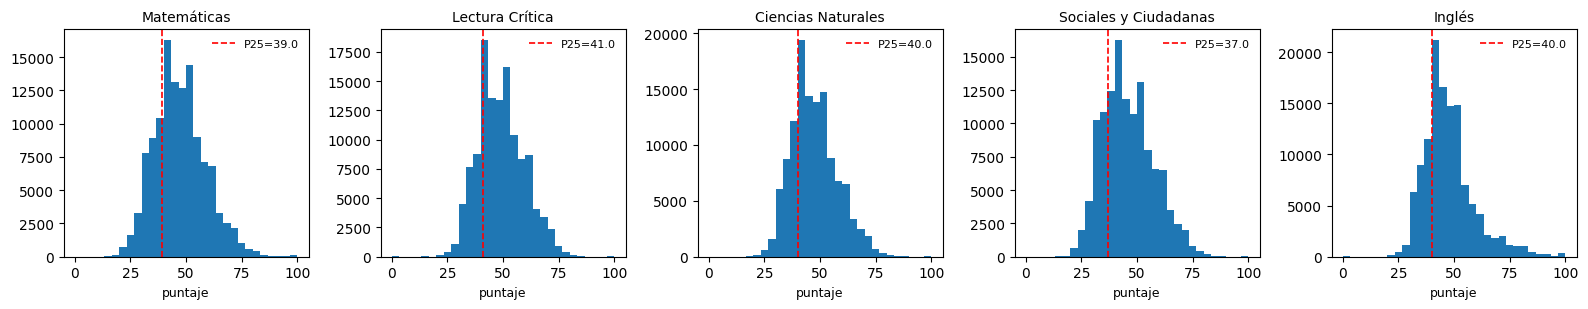

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, (nombre_area, (col_punt, _)) in zip(axes, mapeo_targets.items()):
    serie = df_modelo[col_punt].dropna()
    p25 = percentiles_25_train[nombre_area]
    ax.hist(serie, bins=30)
    ax.axvline(p25, color="red", linestyle="--", linewidth=1.2,
               label=f"P25={p25:.1f}")
    ax.set_title(nombre_area, fontsize=10)
    ax.set_xlabel("puntaje", fontsize=9)
    ax.legend(loc="upper right", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


## 9. Balance de clases por área (train vs test)

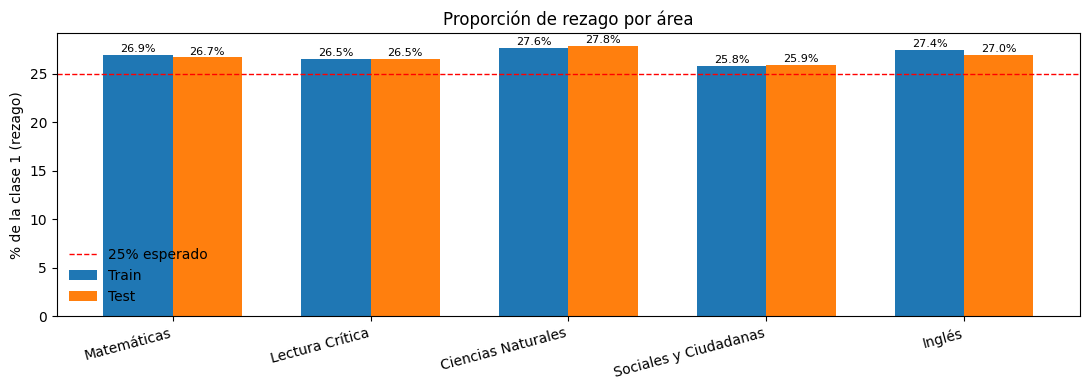

In [9]:
nombres_areas = list(mapeo_targets.keys())
targets_list = [mapeo_targets[a][1] for a in nombres_areas]
pct_train = [y_train_dict[t].mean() * 100 for t in targets_list]
pct_test  = [y_test_dict[t].mean()  * 100 for t in targets_list]

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(nombres_areas))
w = 0.35
b1 = ax.bar(x - w/2, pct_train, w, label="Train")
b2 = ax.bar(x + w/2, pct_test,  w, label="Test")
for bars, vals in [(b1, pct_train), (b2, pct_test)]:
    for bb, v in zip(bars, vals):
        ax.text(bb.get_x() + bb.get_width()/2, v + 0.3, f"{v:.1f}%",
                ha="center", fontsize=8)
ax.axhline(25, color="red", linestyle="--", linewidth=1, label="25% esperado")
ax.set_xticks(x); ax.set_xticklabels(nombres_areas, rotation=15, ha="right")
ax.set_ylabel("% de la clase 1 (rezago)")
ax.set_title("Proporción de rezago por área")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 10. Análisis exploratorio: rezago promedio por categoría

Tasa promedio de rezago (clase 1) según variables socioeconómicas, familiares y escolares. Sirve para conectar el modelo con la pregunta de negocio: las variables del entorno sí parecen estar asociadas con el rezago en las distintas áreas.


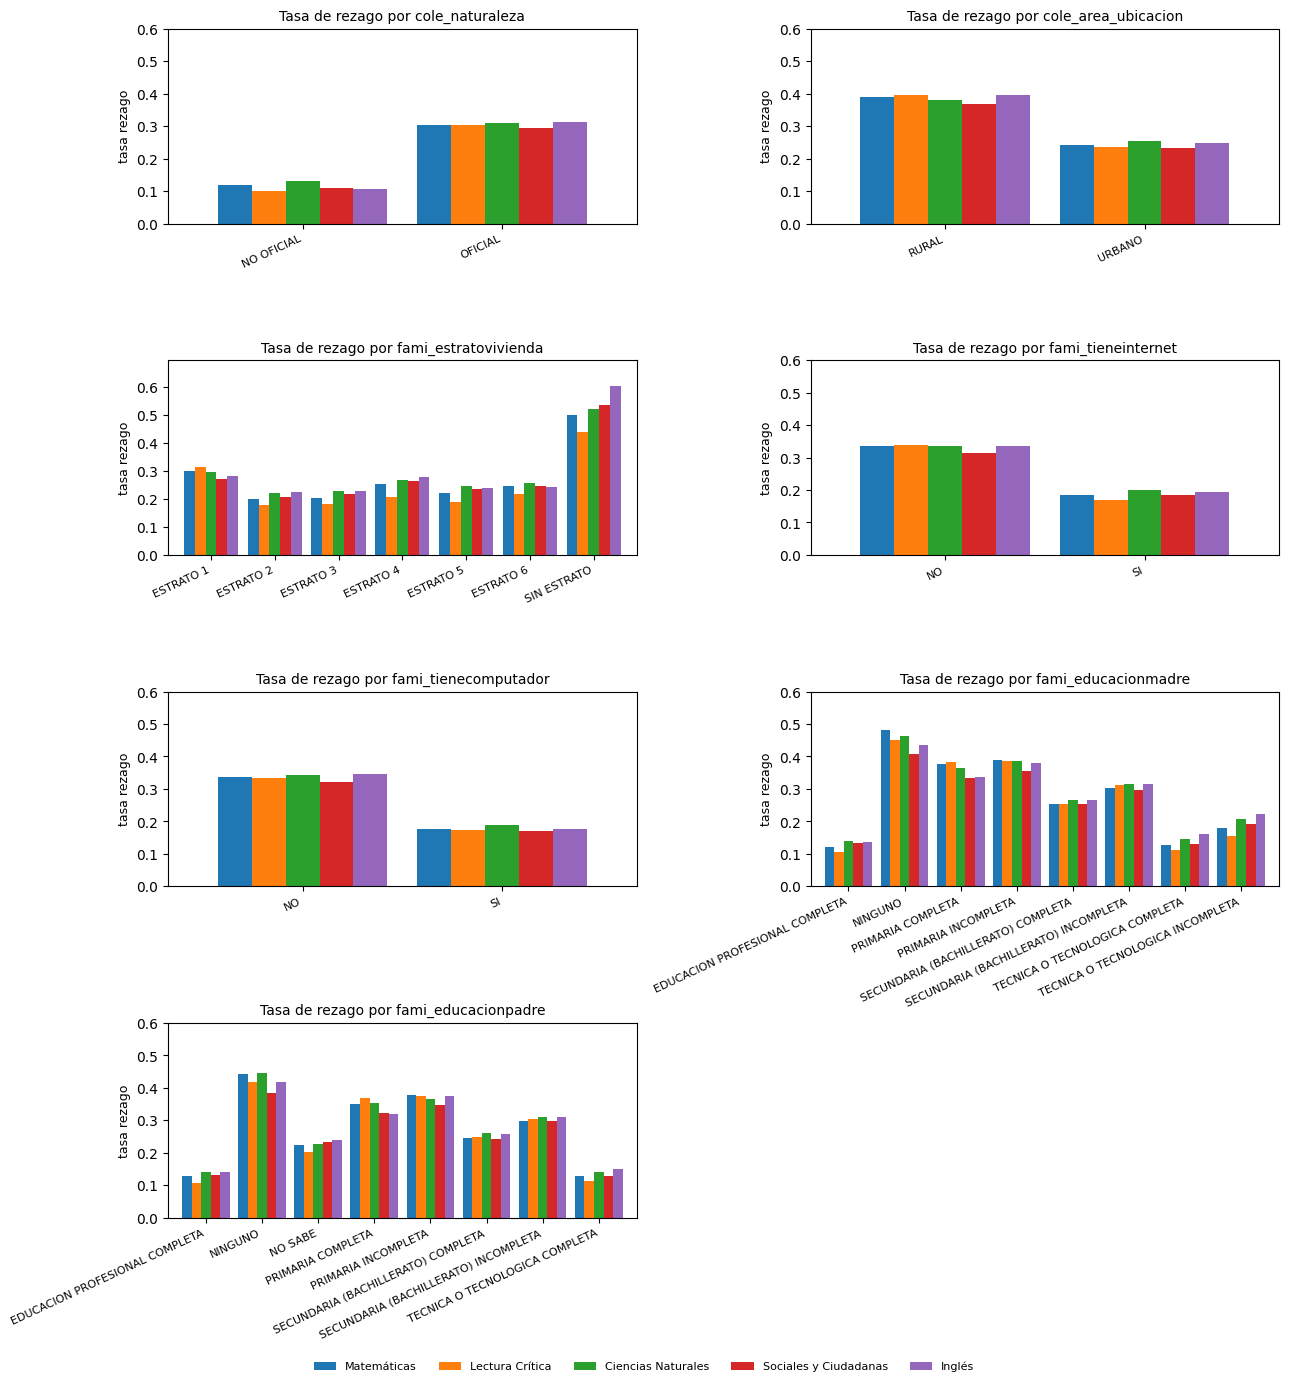

In [10]:
def rezago_promedio_por_categoria(df_eda, variable, targets_list, nombres_areas, max_cats=10):
    """Devuelve un DataFrame con la tasa promedio de rezago por nivel de la variable."""
    if variable not in df_eda.columns:
        return None
    grp = df_eda.groupby(variable)[targets_list].mean()
    # Recorta a las top categorias por tamano si hay demasiadas
    if grp.shape[0] > max_cats:
        top_cats = df_eda[variable].value_counts().nlargest(max_cats).index
        grp = grp.loc[grp.index.intersection(top_cats)]
    grp.columns = nombres_areas
    return grp.sort_index()


def plot_rezago_categorias(df_eda, variable, targets_list, nombres_areas, ax, max_cats=10):
    tabla = rezago_promedio_por_categoria(df_eda, variable, targets_list, nombres_areas, max_cats)
    if tabla is None or tabla.empty:
        ax.set_visible(False)
        return
    tabla.plot(kind="bar", ax=ax, width=0.85, legend=False)
    ax.set_title(f"Tasa de rezago por {variable}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("tasa rezago", fontsize=9)
    ax.set_ylim(0, max(0.6, tabla.values.max() * 1.15))
    for label in ax.get_xticklabels():
        label.set_rotation(25); label.set_ha("right"); label.set_fontsize(8)


variables_eda = [
    "cole_naturaleza", "cole_area_ubicacion", "fami_estratovivienda",
    "fami_tieneinternet", "fami_tienecomputador",
    "fami_educacionmadre", "fami_educacionpadre",
]
variables_eda = [v for v in variables_eda if v in df_eda.columns]

n = len(variables_eda)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.4 * nrows))
axes_flat = np.array(axes).flatten()

for ax, var in zip(axes_flat, variables_eda):
    plot_rezago_categorias(df_eda, var, targets_list, nombres_areas, ax, max_cats=8)

# Apagar ejes sobrantes
for ax in axes_flat[len(variables_eda):]:
    ax.set_visible(False)

# Leyenda comun fuera del area de las graficas
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()
